In [45]:
%matplotlib inline
import pandas as pd
import numpy as np
import os

import nibabel as nb
from nilearn.image import load_img, math_img
from nilearn.datasets import load_mni152_template, fetch_surf_fsaverage
from nilearn import plotting, surface, datasets
from nibabel import load as load_gifti
from nilearn.plotting import plot_stat_map

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps

from neuromaps.datasets import fetch_fslr
from neuromaps.transforms import mni152_to_fslr
from surfplot import Plot
from surfplot.utils import threshold

from matplotlib.colors import LinearSegmentedColormap, Normalize

# Define a gradual change from transparent to opaque red
n_bins = 100  
cmap_name = 'custom_cmap'
color_list = [(1, 0, 0, i / n_bins) for i in range(n_bins + 1)]
single_color_cmap = LinearSegmentedColormap.from_list(cmap_name, color_list, N=n_bins)

template = load_mni152_template(resolution=1)

# Consistent cut coordinates for all plots
common_cut_coords = [-20, 0, 20]  # Adjust these coordinates to your liking

# Wrapper for extracting tmaps
def extract_results_wrapper(df, stat, atlases_nii, atlases_csv, save_path):
    print('Extracting whole-brain maps', end=':')
    # Define atlas names
    parcels_maps = ['schaefer', 'tian_subcortex', 'cerebellum']
    # Extract T-maps for each atlas
    tmaps = {selected_atlas: vals2atlas(df, selected_atlas, atlases_nii, atlases_csv, stat) for selected_atlas in parcels_maps}

    # Handle brainstem separately
    print('\tbrainstem', end='...')
    df_brainstem_results = df[df['Atlas'] == 'brainstem']
    if df_brainstem_results.empty:
        tmap_brainstem_zeros = np.zeros(shape=tmaps['schaefer'].shape)
        tmaps['brainstem'] = nb.Nifti1Image(tmap_brainstem_zeros, header=tmaps['schaefer'].header, affine=tmaps['schaefer'].affine) 
    else:
        tmaps_brainstem = [val2roi_atlas(df_brainstem_results, brainstem_roi, atlases_nii, stat) for brainstem_roi in df_brainstem_results['ROI'].tolist()]
        tmaps['brainstem'] = math_img('np.sum(img, axis=-1)', img=tmaps_brainstem)

    # Combine brain maps
    tmaps['tian_subcortex_brainstem'] = math_img('np.sum(img, axis=-1)', img=[tmaps['tian_subcortex'], tmaps['brainstem']])
    tmaps['wholebrain'] = math_img('np.sum(img, axis=-1)', img=[tmaps['schaefer'], tmaps['tian_subcortex'], tmaps['brainstem'], tmaps['cerebellum']])

    # Save T-maps
    print('Saving...', end=' ')
    for suffix, data in tmaps.items():
        file_path = os.path.join(f'{save_path}_{suffix}.nii.gz')
        nb.save(data, file_path)
    
    print('Done')
    
    return tmaps  # Return the dictionary of T-maps instead of only 'wholebrain'

def save_and_show_plot(fig_brain, filepath_base):
    plt.tight_layout()
    plt.savefig(f'{filepath_base}.svg', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filepath_base}.png', dpi=300, bbox_inches='tight')
    plt.show()

def vals2atlas(df, selected_atlas, atlases_nii, atlases_csv, stat):
    print(f'\t{selected_atlas}...', end='')
    # Load atlas
    selected_atlas_img = load_img(atlases_nii[selected_atlas])
    selected_atlas_img_np = selected_atlas_img.get_fdata()

    n_labels = np.unique(selected_atlas_img_np)[1:]

    atlas_info = pd.read_csv(atlases_csv[selected_atlas])
    atlas_labels = atlas_info['Label Name'].tolist()

    # Subset results data frame and get ROIs
    results_selected_atlas = df[df['Atlas'] == selected_atlas]
    df_atlas_sig_rois = results_selected_atlas.ROI.tolist()

    for i in n_labels:
        # Check if label is in model
        label_i = atlas_labels[int(i) - 1]
        label_contains = label_i in df_atlas_sig_rois
        selected_atlas_img_np[selected_atlas_img_np == i] = 0 if not label_contains else results_selected_atlas.iloc[df_atlas_sig_rois.index(label_i)][stat]

    tmap = nb.Nifti1Image(selected_atlas_img_np, header=selected_atlas_img.header, affine=selected_atlas_img.affine)
    
    return tmap

def val2roi_atlas(df, brainstem_roi, atlases_nii, stat):
    df_brainstem_i = df[df['ROI'] == brainstem_roi]
    i_roi = load_img(os.path.join(atlases_nii['brainstem'], brainstem_roi + '.nii.gz'))
    i_roi_np = i_roi.get_fdata()
    i_roi_np[i_roi_np == 1] = df_brainstem_i[stat].tolist()[0]

    tmap = nb.Nifti1Image(i_roi_np, header=i_roi.header, affine=i_roi.affine)

    return tmap

def plot_single_roi_stat(in_file, out_file, display_mode, black_bg, cut_coords=common_cut_coords):
    img = nb.load(in_file)
    data = img.get_fdata()
    # Set colorbar limits to -1 and 1
    abs_max = 1.0
    fig, axes = plt.subplots(1, 1, figsize=(4, 4))

    return plotting.plot_stat_map(img, output_file=out_file, symmetric_cbar=True, vmin=-abs_max, vmax=abs_max, 
                                  bg_img=template, black_bg=black_bg,
                                  cut_coords=cut_coords, figure=fig, axes=axes,
                                  display_mode=display_mode, threshold=0.0001, cmap=single_color_cmap)


def plot_fig(tmap, nrow, ncol, figsize, annotate=False, save=False, close=False, 
             display_mode='x', labelsize=12, orientation='vertical', cbar_label='ReHo Difference', plot_save_path='figure.png'):
    if isinstance(tmap, str):
        img = nb.load(tmap)
    else:
        img = tmap

    cut_coords = {
        'x': np.linspace(-60, 60, ncol * nrow, dtype=int).tolist(),
        'y': np.linspace(-100, 70, ncol * nrow, dtype=int).tolist(),
        'z': np.linspace(-62, 72, ncol * nrow, dtype=int).tolist()
    }
    print(f'Display mode: {display_mode}, \nCoordinates: {cut_coords[display_mode]}')
    # Set counter
    counter = 0

    # Start plotting
    fig, axes = plt.subplots(nrow, ncol+1, figsize=figsize, gridspec_kw={'width_ratios': [1]*ncol + [0.05]})
    gs = axes[0, ncol].get_gridspec()
    # remove the underlying axes
    for ax in axes[:, -1]:
        ax.remove()
    ax_colorbar = fig.add_subplot(gs[:, -1])

    # Do the brain map 
    for row in range(nrow):
        for col in range(ncol):
            plotting.plot_stat_map(img, title='', black_bg=True, bg_img=template,
                                   axes=axes[row, col], annotate=annotate, 
                                   display_mode=display_mode, symmetric_cbar=True,
                                   colorbar=False, cut_coords=[cut_coords[display_mode][counter]], threshold=0.0001, cmap=single_color_cmap,
                                   vmin=-1.0, vmax=1.0)
            counter += 1

    # Do the colorbar
    font_properties = {'family': 'serif', 'size': labelsize}
    cmap = cm.get_cmap('cold_hot')
    # Set colorbar limits to -1 and 1
    norm = mpl.colors.Normalize(vmin=-1.0, vmax=1.0)
    cb1 = mpl.colorbar.ColorbarBase(ax_colorbar, cmap=cmap, norm=norm, orientation=orientation)
    cb1.set_label(cbar_label)
    cb1.ax.tick_params(labelsize=labelsize)
    cb1.ax.set_yticklabels(cb1.ax.get_yticklabels(), **font_properties)
    
    if save:
        plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
        
    if close:
        plt.close()
        
    return fig, axes

# Plot Cortex surface plot
def plot_surf(tmap, savefile, vmax=1.0, cmap=None, show_figure=False, title=None):
    # Project from MNI to fsLR and threshold after projection to avoid interpolation artifacts
    gii_lh, gii_rh = mni152_to_fslr(tmap)
    data_lh = threshold(gii_lh.agg_data(), 0.0001)
    data_rh = threshold(gii_rh.agg_data(), 0.0001)

    # Get surfaces + sulc maps
    surfaces = fetch_fslr()
    lh, rh = surfaces['inflated']

    # Load sulcal maps as numpy arrays from GIFTI files
    sulc_lh = load_gifti(str(surfaces['sulc'].L)).darrays[0].data
    sulc_rh = load_gifti(str(surfaces['sulc'].R)).darrays[0].data

    p = Plot(lh, rh)
    p.add_layer({'left': sulc_lh, 'right': sulc_rh}, cmap='binary_r', cbar=False)

    # Using 'cold_hot' as a common diverging colormap for neuroimaging
    if cmap is None:
        cmap = 'cold_hot'
    p.add_layer({'left': data_lh, 'right': data_rh}, cmap=cmap, color_range=(-vmax, vmax))

    # Adjust colorbar settings
    kws = dict(location='right', draw_border=True, aspect=5, shrink=0.2, decimals=3, pad=0)
    fig = p.build(cbar_kws=kws)
    if title:
        fig.suptitle(title, fontsize=16)
    fig.savefig(savefile, bbox_inches='tight', dpi=600, transparent=True)
    if show_figure:
        fig.show()
    else:
        plt.close(fig)

def plot_subcortex(tmap_wholebrain, savefile, cut_coords=None, display_mode='ortho', cmap=None):
    # data = tmap_wholebrain.get_fdata()
    # if np.count_nonzero(data) == 0:
    #     print("Subcortex+brainstem tmap is empty.")
    #     return
    
    # Find the MNI coordinates of the activation
    if cut_coords is None:
        coords = plotting.find_xyz_cut_coords(tmap_wholebrain, activation_threshold=0.0001)
    else:
        coords = cut_coords
    print("MNI coordinates for subcortex+brainstem:", coords)

    # Plot using plot_stat_map
    display = plotting.plot_stat_map(
        tmap_wholebrain,
        display_mode=display_mode,
        cut_coords=coords,
        colorbar=True,
        cmap=cmap if cmap else 'cold_hot',
        black_bg=True,
        draw_cross=True,
        threshold=0.0001,  # Adjust as needed
        vmin=-1.0, vmax=1.0  # Set colorbar limits to -1 and 1
    )
    
    # Save figure
    display.savefig(savefile, dpi=600)
    #display.show()
    #plt.close(display.frame_figure)  # Close the plot properly after saving

# Plot cerebellum
def plot_cerebellum(tmap_cerebellum, savefile, cut_coords, display_mode, cmap=None):
    data = tmap_cerebellum.get_fdata()
    if np.count_nonzero(data) == 0:
        print("Cerebellum tmap is empty.")
        return

    print("MNI coordinates for cerebellum:", cut_coords)
    
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot using plot_stat_map
    display = plotting.plot_stat_map(
        tmap_cerebellum,
        title='Cerebellum',
        bg_img=template,
        display_mode=display_mode,
        cut_coords=cut_coords,
        colorbar=True,
        cmap=cmap if cmap else 'cold_hot',
        black_bg=True,
        draw_cross=True,
        threshold=0.0001,  # Adjust as needed
        figure=fig,
        axes=ax,
        vmin=-1.0, vmax=1.0  # Set colorbar limits to -1 and 1
    )
    
    # Adjust colorbar font size by locating the colorbar axis
    for axis in fig.axes:
        if axis != ax:
            # This is the colorbar axis
            axis.set_ylabel('Statistical Value', fontsize=12)
            axis.tick_params(labelsize=10)
    
    plt.tight_layout()
    plt.savefig(savefile, dpi=1200)
    plt.show()
    plt.close(fig)


# Attempt to fetch fsaverage directly here with error handling
try:
    fsaverage = datasets.fetch_surf_fsaverage()
except AttributeError as e:
    print("Error fetching fsaverage. Check Nilearn installation. Error:", e)
    fsaverage = None

Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Extracting whole-brain maps:	schaefer...	tian_subcortex...	cerebellum...	brainstem...Saving... Done
Plotting cortex using plot_surf...


C:\Users\puneet\AppData\Local\Temp\ipykernel_29116\1871928253.py:204: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



----------
Plotting subcortex + brainstem...
MNI coordinates for subcortex+brainstem: [-30, -25, -20, -15, -10, -5, 0]

----------
Plotting cerebellum...
Cerebellum tmap is empty.


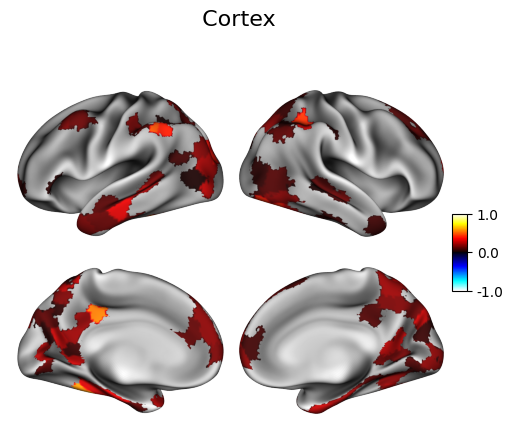

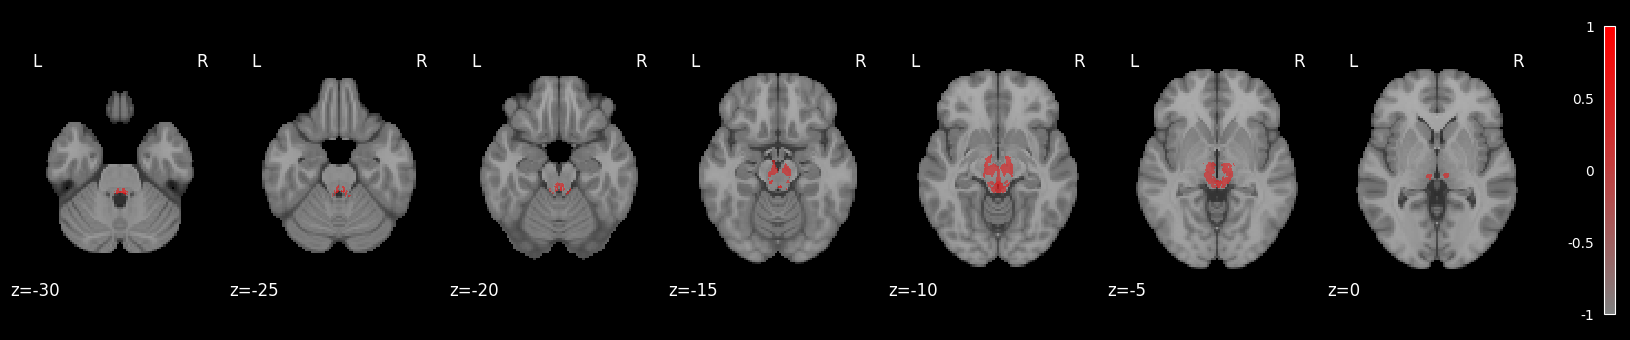

In [46]:
# Set up directories and files
dirs = {
    'atlas': '../atlas',
    'stat': '../stat',
    'fig': '../fig',
    'stat_maps': '../stat/maps'
}

atlases_nii = {
    'schaefer': os.path.join(dirs['atlas'], 'schaefer', 'Reslice_400Parcels_7Networks.nii.gz'),
    'tian_subcortex': os.path.join(dirs['atlas'], 'tian_subcortex', 'Reslice_tian_subcortex_S2_7T.nii.gz'),
    'cerebellum': os.path.join(dirs['atlas'], 'cerebellum', 'Reslice_MDTB10-cerebellum.nii.gz'),
    'brainstem': os.path.join(dirs['atlas'], 'brainstem', 'resampled_rois/')
}
atlases_csv = {
    'schaefer': os.path.join(dirs['atlas'], 'schaefer', '400parcels_7networks.csv'),
    'tian_subcortex': os.path.join(dirs['atlas'], 'tian_subcortex', 'tian_subcortex_S2.csv'),
    'brainstem': os.path.join(dirs['atlas'], 'brainstem', 'brainstem_54.csv'),
    'cerebellum': os.path.join(dirs['atlas'], 'cerebellum', 'MDTB10-cerebellum.csv')
}

# Create toggles
toggles = {
    'create_tmaps': True,  # Use existing maps instead of creating new ones.
    'plot_cortex': True,
    'plot_subcortex': True,
    'plot_cerebellum': True,
    'plot_colorbar': False,
}

# Specify the machine learning algorithm or identifier for the filename
ML_algorithm = ''

# ## For a single .csv file
# # Read the single CSV file (test.csv)
# df_results = pd.read_csv(os.path.join(dirs['stat'], 'test.csv'))
# df_results['ROI'] = df_results['ROI'].str.replace('.', '-')
# score_filter = 0.0001
# df_results = df_results[(df_results['Weights'] > score_filter) | (df_results['Weights'] < -score_filter)]
# output_path = os.path.join(dirs['stat_maps'], f'results_{ML_algorithm}')
# # Extract results into brain
# tmaps = extract_results_wrapper(df_results, 'Weights', atlases_nii, atlases_csv, output_path)

## For all the .csv files in the 'stat' folder -- #### Read all the score files from /stat; save plots for them in /fig folder.
csv_files = glob.glob(os.path.join(dirs['stat'], '*.csv'))

for csv_file in csv_files:
    df_results = pd.read_csv(csv_file)
    csv_filename = os.path.basename(csv_file)
    csv_basename = os.path.splitext(csv_filename)[0]
    df_results['ROI'] = df_results['ROI'].str.replace('.', '-')
    score_filter = 0.0001
    df_results = df_results[(df_results['Weights'] > score_filter) | (df_results['Weights'] < -score_filter)]
    output_path = os.path.join(dirs['stat_maps'], f'results_{csv_basename}')

    # Extract results into brain maps
    tmaps = extract_results_wrapper(df_results, 'Weights', atlases_nii, atlases_csv, output_path)
    
if toggles['plot_cortex']:
    schaefer_results = os.path.join(dirs['stat_maps'], f'results_{ML_algorithm}_schaefer.nii.gz')
    tmap_schaefer = nb.load(schaefer_results)
    
    # Check if tmap_schaefer is a valid Nifti image
    if isinstance(tmap_schaefer, nb.Nifti1Image):
        print("Plotting cortex using plot_surf...")
        savefile = os.path.join(dirs['fig'], f'results_{ML_algorithm}_cortex.png')
        plot_surf(tmap_schaefer, savefile, show_figure=True, title=f'{ML_algorithm} Cortex')
    else:
        print("Unable to plot cortex: Invalid NIfTI image.")

if toggles['plot_subcortex']:
    subcortex_brainstem_results = os.path.join(dirs['stat_maps'], f'results_{ML_algorithm}_tian_subcortex_brainstem.nii.gz')
    tmap_subcortex_brainstem = nb.load(subcortex_brainstem_results)
    
    # Define display parameters for subcortex
    subcortex_cut_coords = [-30, -25, -20, -15, -10, -5, 0]  # Example coordinates
    display_mode_subcortex = 'z'  # Example display mode

    print("\n----------\nPlotting subcortex + brainstem...")
    savefile_subcortex = os.path.join(dirs['fig'], f'results_{ML_algorithm}_subcortex_brainstem.png')
    plot_subcortex(tmaps['tian_subcortex_brainstem'], savefile_subcortex, subcortex_cut_coords, display_mode_subcortex, cmap=single_color_cmap)

if toggles['plot_cerebellum']:
    cerebellum_results = os.path.join(dirs['stat_maps'], f'results_{ML_algorithm}_cerebellum.nii.gz')
    tmap_cerebellum = nb.load(cerebellum_results)
    
    # Define display parameters for cerebellum
    cerebellum_cut_coords = [-70, -65, -60, -55, -50]  # Example coordinates
    display_mode_cerebellum = 'z'  # Example display mode

    print("\n----------\nPlotting cerebellum...")
    savefile_cerebellum = os.path.join(dirs['fig'], f'results_{ML_algorithm}_cerebellum.png')
    plot_cerebellum(tmap_cerebellum, savefile_cerebellum, cerebellum_cut_coords, display_mode_cerebellum)

### Plotting Sub-cortex + Brainstem
- enter corresponding subcortex/tian map, run this cell
- find x coordinates for left and right hemisphere => set cut_coors =[x1, x2] 
- run next cell, call plot_subcortex => plot will be displayed and saved in ../fig

C:\Users\puneet\.conda\envs\MRP\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



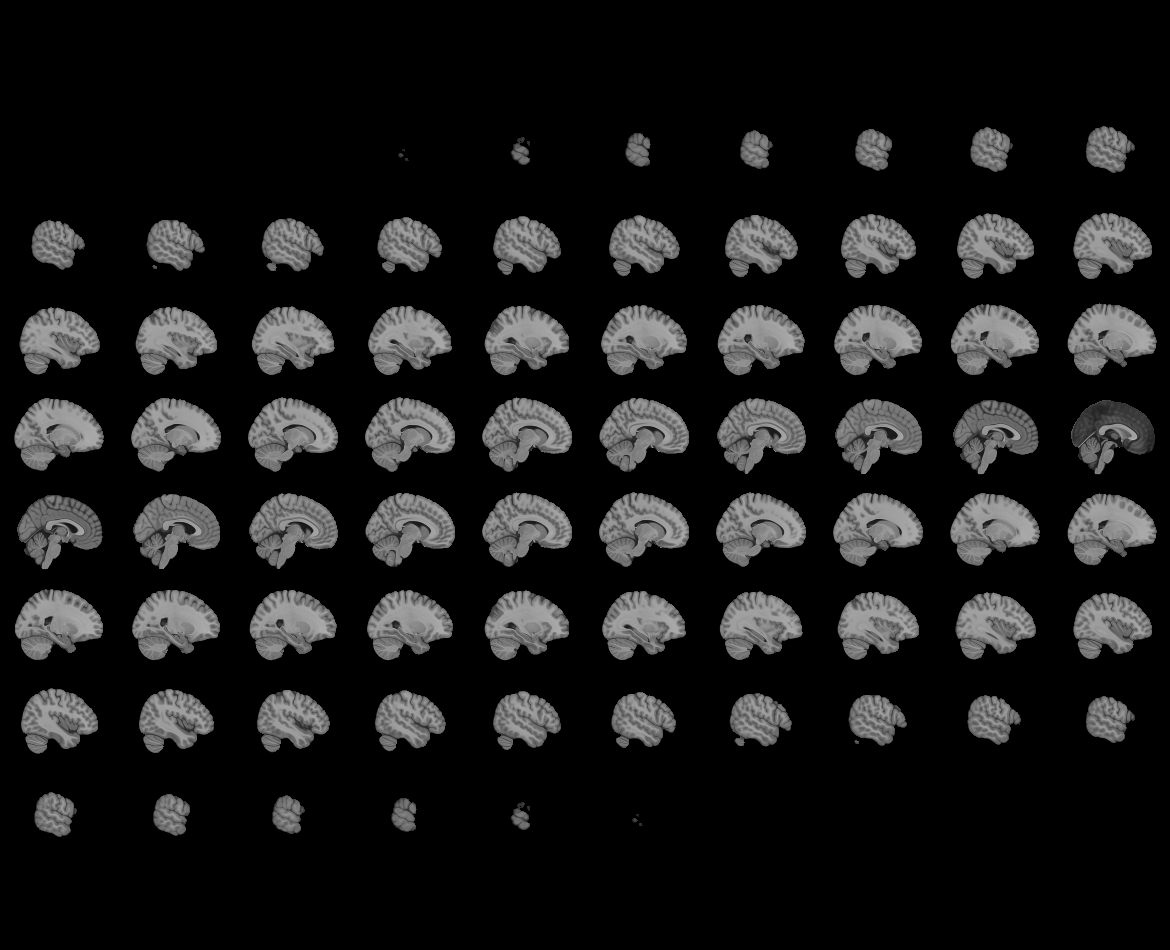
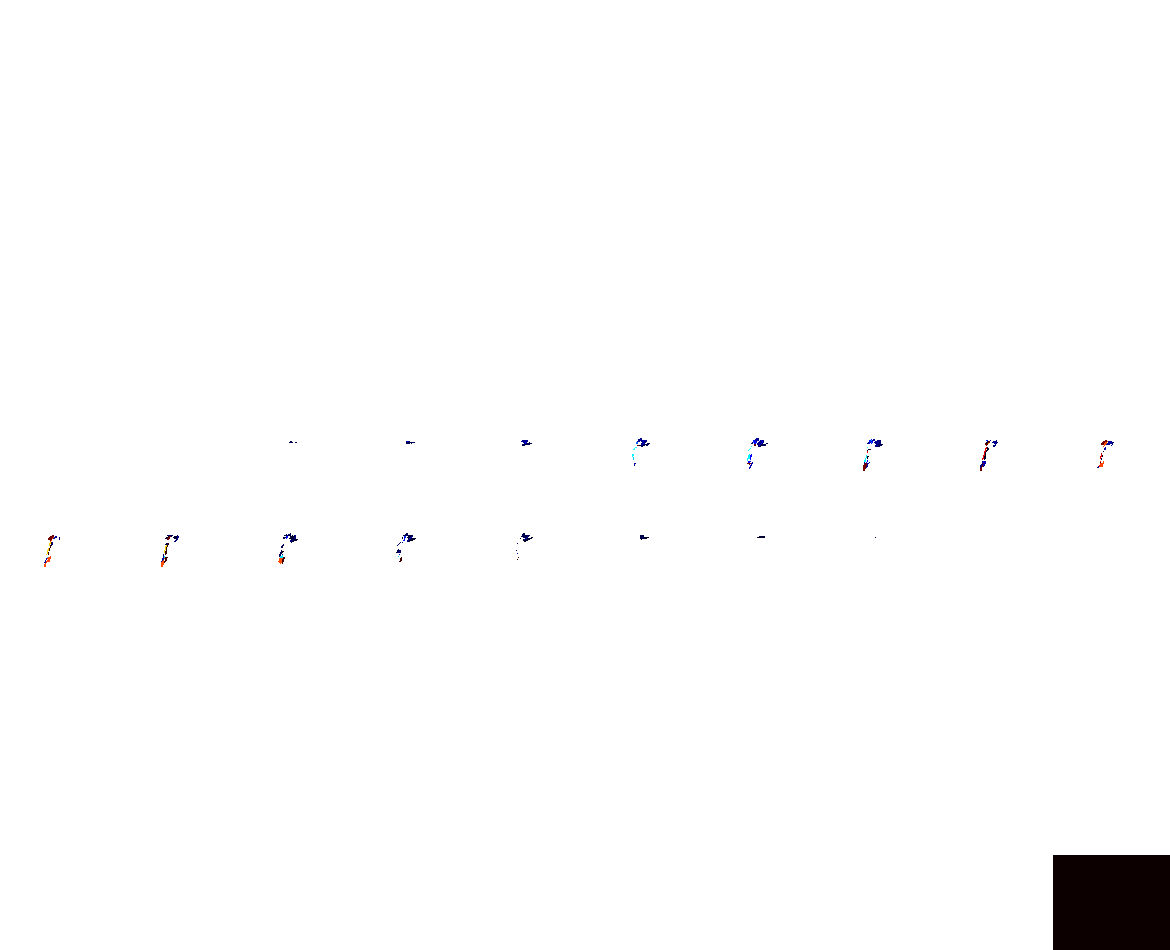

In [51]:
from nilearn import plotting
map = '../stat/maps/results_diff_j1_vs_j6_tian_subcortex_brainstem.nii.gz'
plotting.view_img(map)

MNI coordinates for subcortex+brainstem: [-2, 8]


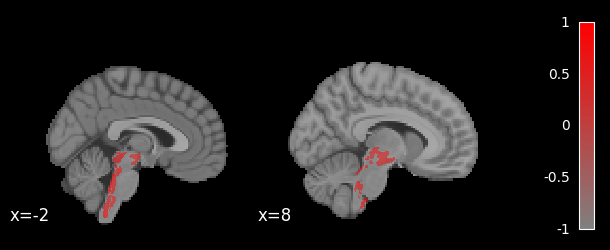

In [53]:
import matplotlib.pyplot as plt
usecase = '_'.join(map.split('/')[-1].split('_')[1:5]) 
savefile = os.path.join('../fig', f'{usecase}_subcortex_brainstem.png') 

plot_subcortex(map, savefile, cut_coords=[-2,8], display_mode='x', cmap=single_color_cmap)

### Plotting Cerebellum...
 https://suitpy.readthedocs.io/en/latest/notebooks/flatmap_example.html 

### Generate the CSV files with ReHo values' difference 
#### for j1 vs j2 pair, Weight = avg ReHo value for j2 - avg ReHo value for j1

In [36]:
import pandas as pd
import os
import glob

# Define the path to the ReHo data and atlas directory
data_path = '../data/reho_output.csv'
atlas_dir = '../data/atlas/'

# Load the dataset
reho_data = pd.read_csv(data_path)

# Filter data for 'task-jhana' only
jhana_data = reho_data[reho_data['task'] == 'task-jhana']

# Group by 'segment' to get average ReHo values for each Jhana state
jhana_means = jhana_data.groupby('segment').mean(numeric_only=True)

# Prepare a dictionary to map ROI to Atlas
atlas_mapping = {}
atlas_files = glob.glob(atlas_dir + '*.csv')
for atlas_file in atlas_files:
    atlas_name = os.path.splitext(os.path.basename(atlas_file))[0]
    atlas_df = pd.read_csv(atlas_file)
    for roi in atlas_df['Label Name']:
        normalized_roi = roi.replace('.', '-')
        atlas_mapping[normalized_roi] = atlas_name

# Define the pairs of Jhana states to compare
pairs = [
    ('j1', 'j2'),
    ('j2', 'j3'),
    ('j3', 'j4'),
    ('j4', 'j5'),
    ('j5', 'j6'),
    ('j1', 'j6')
]

# Calculate differences for each pair and save as CSV
for first, second in pairs:
    # Compute the difference between the two states (second - first)
    difference = jhana_means.loc[second] - jhana_means.loc[first]
    
    # Convert the Series to DataFrame and ensure the 'index' is named 'ROI'
    difference_df = difference.to_frame(name='Weights').reset_index()
    difference_df.rename(columns={'index': 'ROI'}, inplace=True)  # Ensure the column is named 'ROI'
    difference_df['ROI'] = difference_df['ROI'].apply(lambda x: x.replace('.', '-'))
    difference_df['Atlas'] = difference_df['ROI'].apply(lambda x: atlas_mapping.get(x, 'Unknown'))

    # Debugging: Print unknown atlas ROIs
    unknown_rois = difference_df[difference_df['Atlas'] == 'Unknown']['ROI']
    if not unknown_rois.empty:
        print(f"Unknown ROIs for {first} vs {second}: {unknown_rois.tolist()}")

    # Reorder columns to match required format
    difference_df = difference_df[['Atlas', 'ROI', 'Weights']]
    
    # Save to CSV
    output_csv_path = f'../stat/{first}_vs_{second}.csv'
    difference_df.to_csv(output_csv_path, index=False)

    print(f'Saved {output_csv_path}')

Saved ../stat/j1_vs_j2.csv
Saved ../stat/j2_vs_j3.csv
Saved ../stat/j3_vs_j4.csv
Saved ../stat/j4_vs_j5.csv
Saved ../stat/j5_vs_j6.csv
Saved ../stat/j1_vs_j6.csv
